# AutoML percentile correction on Favorita Grocery Sales (XGBoost, Weekday-Aware)

This version selects percentiles by overall **MSE** (metric mode).


## Weekday Percentile Correction (How To Use)

This notebook uses weekday-aware percentile correction, where the mapping key is `(unique_id, weekday)` and weekday follows pandas convention (`0=Mon, ..., 6=Sun`).

Set `PERCENTILE_CORRECTION_BY_WEEKDAY = True` in the training loop cell and pass:

- `percentile_correction=True`
- `percentile_correction_mode="bias"` or `"metric"`
- `percentile_correction_by_weekday=True`

Then inspect `auto_corr.percentile_correction_["xgb"]["id_to_col"]` to see selections like `("id", 0) -> xgb-lo-10` and `("id", 6) -> xgb-hi-20`.

In [2]:
# Minimal switch for weekday-aware correction
PERCENTILE_CORRECTION_BY_WEEKDAY = True

# Inside auto_corr.fit(...)
# percentile_correction=True
# percentile_correction_mode="bias"   # or "metric"
# percentile_correction_by_weekday=PERCENTILE_CORRECTION_BY_WEEKDAY


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from mlforecast.auto import xgboost_space
import optuna

from utilsforecast.losses import rmse, mse, bias, mae

def eval_metrics(valid_df, preds_df, model_col: str):
    df = valid_df.merge(preds_df, on=["unique_id", "ds"], how="inner")
    return {
        "rows": len(df),
        "rmse": float(rmse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mse": float(mse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "bias": float(bias(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mae": float(mae(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
    }

def rmse_loss(df, train_df):  # train_df is unused here
    # df has columns: ['unique_id', 'ds', 'cutoff', 'y', 'model']
    return rmse(df, models=['model'], id_col='unique_id', target_col='y')['model'].mean()


/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_dir = 'data'
favorita_group = 'Favorita200'  # 'Favorita200' or 'FavoritaComplete'
favorita_dir = f'{data_dir}/favorita'
favorita_start_date = '2017-01-01'

def coerce_favorita_ds(ds):
    ds = pd.Series(ds)
    if pd.api.types.is_datetime64_any_dtype(ds):
        return pd.to_datetime(ds)

    numeric = pd.to_numeric(ds, errors='coerce')
    if numeric.notna().all():
        values = numeric.astype('int64')
        if values.abs().max() > 10**14:
            return pd.to_datetime(values, unit='ns')
        if values.abs().max() > 10**11:
            return pd.to_datetime(values, unit='ms')
        return pd.to_datetime(values, unit='s')

    return pd.to_datetime(ds)


def read_favorita_table(directory, name, usecols=None, dtype=None):
    feather_path = f'{directory}/{name}.feather'
    csv_path = f'{directory}/{name}.csv'
    if pd.io.common.file_exists(feather_path):
        df = pd.read_feather(feather_path)
        if usecols is not None:
            existing = [c for c in usecols if c in df.columns]
            df = df[existing].copy()
        return df
    if pd.io.common.file_exists(csv_path):
        kwargs = {}
        if usecols is not None:
            kwargs['usecols'] = lambda c: c in set(usecols)
        if dtype is not None:
            kwargs['dtype'] = dtype
        return pd.read_csv(csv_path, **kwargs)
    raise FileNotFoundError(f'Favorita file {name} not found in {directory} as feather or csv.')


def load_favorita_bottom(directory, group='Favorita200', start_date='2017-01-01'):
    temporal = read_favorita_table(
        directory,
        'train',
        usecols=['date', 'item_nbr', 'store_nbr', 'unit_sales', 'onpromotion'],
    )

    temporal = temporal.rename(columns={'date': 'ds', 'unit_sales': 'y'})
    temporal['ds'] = coerce_favorita_ds(temporal['ds'])
    temporal['y'] = pd.to_numeric(temporal['y'], errors='coerce').fillna(0.0).astype('float32')
    temporal['onpromotion'] = pd.to_numeric(temporal.get('onpromotion', 0), errors='coerce').fillna(0).astype('int8')
    temporal['item_nbr'] = pd.to_numeric(temporal['item_nbr'], errors='coerce').astype('int32')
    temporal['store_nbr'] = pd.to_numeric(temporal['store_nbr'], errors='coerce').astype('int16')

    temporal = temporal[temporal['ds'] >= pd.Timestamp(start_date)].copy()

    all_items = np.sort(temporal['item_nbr'].unique())
    if group == 'Favorita200':
        rng = np.random.default_rng(1)
        items = np.sort(rng.choice(all_items, size=200, replace=False))
    elif group == 'Favorita500':
        rng = np.random.default_rng(1)
        items = np.sort(rng.choice(all_items, size=500, replace=False))
    elif group == 'FavoritaComplete':
        items = all_items
    else:
        raise ValueError('group must be one of Favorita200, Favorita500, FavoritaComplete')

    temporal = temporal[temporal['item_nbr'].isin(items)].copy()
    stores = np.sort(temporal['store_nbr'].unique())

    temporal = (
        temporal.groupby(['item_nbr', 'store_nbr', 'ds'], as_index=False)
        .agg(y=('y', 'sum'), onpromotion=('onpromotion', 'max'))
    )

    items_meta = read_favorita_table(directory, 'items', usecols=['item_nbr', 'family', 'perishable'])
    items_meta['item_nbr'] = pd.to_numeric(items_meta['item_nbr'], errors='coerce').astype('int32')
    items_meta = items_meta[items_meta['item_nbr'].isin(items)].copy()
    items_meta['family'] = items_meta['family'].fillna('unknown').astype('string')
    items_meta['perishable'] = pd.to_numeric(items_meta.get('perishable', 0), errors='coerce').fillna(0).astype('int8')

    stores_meta = read_favorita_table(directory, 'stores', usecols=['store_nbr', 'city', 'type'])
    stores_meta['store_nbr'] = pd.to_numeric(stores_meta['store_nbr'], errors='coerce').astype('int16')
    stores_meta = stores_meta[stores_meta['store_nbr'].isin(stores)].copy()
    stores_meta['city'] = stores_meta['city'].fillna('unknown').astype('string')
    stores_meta['type'] = stores_meta['type'].fillna('unknown').astype('string')

    transactions = read_favorita_table(directory, 'transactions', usecols=['date', 'store_nbr', 'transactions'])
    transactions = transactions.rename(columns={'date': 'ds'})
    transactions['ds'] = coerce_favorita_ds(transactions['ds'])
    transactions['store_nbr'] = pd.to_numeric(transactions['store_nbr'], errors='coerce').astype('int16')
    transactions['transactions'] = pd.to_numeric(transactions['transactions'], errors='coerce').fillna(0).astype('float32')
    transactions = transactions[transactions['store_nbr'].isin(stores)].copy()

    oil = read_favorita_table(directory, 'oil', usecols=['date', 'dcoilwtico'])
    oil = oil.rename(columns={'date': 'ds', 'dcoilwtico': 'oil_price'})
    oil['ds'] = coerce_favorita_ds(oil['ds'])
    oil['oil_price'] = pd.to_numeric(oil['oil_price'], errors='coerce')

    holidays = read_favorita_table(directory, 'holidays_events', usecols=['date', 'transferred'])
    holidays = holidays.rename(columns={'date': 'ds'})
    holidays['ds'] = coerce_favorita_ds(holidays['ds'])
    holidays['transferred'] = holidays['transferred'].astype(str).str.lower().isin(['true', '1', 'yes']).astype('int8')
    holidays = holidays.groupby('ds', as_index=False).agg(transferred=('transferred', 'max'))

    date_min = temporal['ds'].min()
    date_max = temporal['ds'].max()
    dates = pd.date_range(date_min, date_max, freq='D')

    grid = pd.MultiIndex.from_product(
        [items, stores, dates],
        names=['item_nbr', 'store_nbr', 'ds'],
    ).to_frame(index=False)

    oil_full = pd.DataFrame({'ds': dates}).merge(oil, on='ds', how='left')
    oil_full['oil_price'] = oil_full['oil_price'].interpolate(limit_direction='both').ffill().bfill().astype('float32')

    full = (
        grid
        .merge(temporal, on=['item_nbr', 'store_nbr', 'ds'], how='left')
        .merge(items_meta, on='item_nbr', how='left')
        .merge(stores_meta, on='store_nbr', how='left')
        .merge(transactions, on=['store_nbr', 'ds'], how='left')
        .merge(oil_full, on='ds', how='left')
        .merge(holidays, on='ds', how='left')
    )

    full['y'] = full['y'].fillna(0.0).astype('float32')
    full['onpromotion'] = full['onpromotion'].fillna(0).astype('int8')
    full['transactions'] = full['transactions'].fillna(0.0).astype('float32')
    full['oil_price'] = full['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
    full['transferred'] = full['transferred'].fillna(0).astype('int8')
    full['family'] = full['family'].fillna('unknown').astype('category')
    full['city'] = full['city'].fillna('unknown').astype('category')
    full['type'] = full['type'].fillna('unknown').astype('category')
    full['item_nbr'] = full['item_nbr'].astype('Int32').astype('category')
    full['store_nbr'] = full['store_nbr'].astype('Int16').astype('category')
    full['perishable'] = full['perishable'].fillna(0).astype('int8')

    full['unique_id'] = (
        full['item_nbr'].astype(str) + '__store_' + full['store_nbr'].astype(str)
    )

    cols = [
        'unique_id', 'ds', 'y',
        'item_nbr', 'store_nbr', 'family', 'city', 'type',
        'onpromotion', 'perishable', 'transferred',
        'transactions', 'oil_price',
    ]
    return full[cols].sort_values(['unique_id', 'ds']).reset_index(drop=True)

df = load_favorita_bottom(
    directory=favorita_dir,
    group=favorita_group,
    start_date=favorita_start_date,
)

# Optional: subsample ids for faster experiments
MAX_IDS = 50
all_ids = df['unique_id'].unique()
if MAX_IDS is not None and len(all_ids) > MAX_IDS:
    rng = np.random.default_rng(0)
    keep_ids = rng.choice(all_ids, size=MAX_IDS, replace=False)
    df = df[df['unique_id'].isin(keep_ids)].copy()

h = 7
season_length = 7

# Percentile levels used for correction (customizable)


In [5]:
df.shape

(11350, 3)

In [6]:
def rolling_holdout_splits(df, h, n_test_sets, time_col='ds'):
    # assume all ids share same ds grid
    all_ds = pd.to_datetime(sorted(df[time_col].unique()))
    max_ds = all_ds[-1]
    step = pd.Timedelta(days=h)

    for k in range(n_test_sets):
        test_end = max_ds - k * step
        test_start = test_end - pd.Timedelta(days=h - 1)

        train = df[df[time_col] < test_start]
        test = df[(df[time_col] >= test_start) & (df[time_col] <= test_end)]

        yield k, train.reset_index(drop=True), test.reset_index(drop=True)


In [7]:
def tweedie_space(trial):
    params = xgboost_space(trial)
    params["objective"] = "reg:tweedie"
    params["tweedie_variance_power"] = 1.3
    params["eval_metric"] = "tweedie-nloglik@1.5"
    return params


In [ ]:
from sklearn.preprocessing import FunctionTransformer
from mlforecast.target_transforms import LocalStandardScaler, GlobalSklearnTransformer

from mlforecast.lag_transforms import (RollingMean, ExponentiallyWeightedMean, ExpandingMax, ExpandingMin,
                                       RollingStd)

LAGS = [
   # [1],
   # [1, 2, 3],
   # [1, 2, 3, 7],
   # [1, 7, 14],
    [1, 7, 14, 28],
]

LAG_TRANSFORMS = [
    {1: [ExponentiallyWeightedMean(0.9),
         ExpandingMax(),
         ExpandingMin(),
         RollingStd(window_size=7, min_samples=1),
         RollingStd(window_size=14, min_samples=3),
         RollingMean(window_size=7, min_samples=1),
         RollingMean(window_size=14, min_samples=3),
         RollingMean(window_size=30, min_samples=3),
         ]
     },
   # {
   #     1: [ExponentiallyWeightedMean(0.9)],
   #     7: [RollingMean(window_size=3, min_samples=1)],
   # },
]

DATE_FEATURES = ["year", "month", "week", "weekday"]  # standard calendar features

def my_init_config(trial):
    lags_idx = trial.suggest_int("lags_idx", 0, len(LAGS) - 1)
    ltfm_idx = trial.suggest_int("lag_tfms_idx", 0, len(LAG_TRANSFORMS) - 1)
    return {
        "target_transforms": None,   # no differencing
        "lags": LAGS[lags_idx],
        "lag_transforms": LAG_TRANSFORMS[ltfm_idx],
        "date_features": None,
    }


In [9]:
df.shape

(11350, 3)

In [ ]:
STATIC_FEATURES = ['item_nbr', 'store_nbr', 'family', 'city', 'type', 'perishable']
DYNAMIC_FEATURES = ['onpromotion', 'transactions', 'oil_price', 'transferred']
FUTURE_EXOG_COLS = ['unique_id', 'ds'] + DYNAMIC_FEATURES

def my_fit_config(trial):
    return {
        "dropna": False,
        "static_features": STATIC_FEATURES,
    }
    
# Percentile levels used for correction (customizable)
CORRECTION_LEVELS = list(range(1,75, 1))
PERCENTILE_CORRECTION_BY_WEEKDAY = True  # False -> one percentile per unique_id over the full horizon
WEEKDAY_NAME_MAP = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun',
}


def build_selected_map_df(corr):
    rows = []
    by_weekday = corr.get('by_weekday', False)
    by_horizon = corr.get('by_horizon', False)

    for key, selected_col in corr['id_to_col'].items():
        row = {'selected_col': selected_col}
        if by_weekday:
            unique_id, weekday = key
            row['unique_id'] = unique_id
            row['weekday'] = int(weekday)
            row['selected_weekday_name'] = WEEKDAY_NAME_MAP.get(int(weekday))
        elif by_horizon:
            unique_id, horizon = key
            row['unique_id'] = unique_id
            row['horizon'] = int(horizon)
        else:
            row['unique_id'] = key
        rows.append(row)

    selected_map_df = pd.DataFrame(rows)
    if selected_map_df.empty:
        return selected_map_df

    selected_parts = selected_map_df['selected_col'].str.extract(
        r'^(?P<model>.+)-(?P<selected_side>lo|hi)-(?P<selected_percentile>\d+(?:\.\d+)?)$'
    )
    selected_map_df = pd.concat([selected_map_df, selected_parts], axis=1)
    selected_map_df['selected_percentile'] = pd.to_numeric(
        selected_map_df['selected_percentile'], errors='coerce'
    )
    selected_map_df['correction_granularity'] = (
        'weekday' if by_weekday else 'horizon' if by_horizon else 'id'
    )
    return selected_map_df


season_length = 7
h = 7
n_windows = 5
step_size = 7
num_samples = 20
    
n_test_sets = 15

rmse_base_test = []
mse_base_test = []
mae_base_test = []
bias_base_test = []

rmse_corr_test = []
mse_corr_test = []
mae_corr_test = []
bias_corr_test = []

cv_rmse_normal_cv = []
cv_bias_normal_cv = []

cv_rmse_corr_cv = []
cv_bias_corr_cv = []

rmse_base_only_corrected_test = []
mse_base_only_corrected_test = []
mae_base_only_corrected_test = []
bias_base_only_corrected_test = []

rmse_corr_only_corrected_test = []
mse_corr_only_corrected_test = []
mae_corr_only_corrected_test = []
bias_corr_only_corrected_test = []

delta_corr = []
delta_raw = []

share_correction = []
p_val_cv = []

group_sum_records = []
group_correction_records = []
forecast_records = []
selected_percentile_records = []
fold_metric_records = []
train_history_records = []

def xgb_space_with_native_cats(trial):
    params = xgboost_space(trial)
    params["objective"] = "reg:tweedie"
    params["tweedie_variance_power"] = 1.5
    #params["eval_metric"] = "tweedie-nloglik@1.5"
    params.update({
        'enable_categorical': True,
        'tree_method': 'hist',
    })
    return params

for i, train_i, test_i in rolling_holdout_splits(df, h, n_test_sets):
    from mlforecast.auto import AutoMLForecast, AutoXGBoost, PredictionIntervals, xgboost_space
    
    auto_corr = AutoMLForecast(
        models={"xgb": AutoXGBoost(config=xgb_space_with_native_cats)},
        freq="D",
        init_config=my_init_config,
        fit_config=my_fit_config,
        reuse_cv_splits=True
    )
    
    print(i, train_i.ds.min(), train_i.ds.max(), " | ", test_i.ds.min(), test_i.ds.max())

    length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()
    good_ids = length_ids[length_ids.ds > 55].unique_id.unique()

    train_i = train_i[train_i.unique_id.isin(good_ids)].copy()
    test_i = test_i[test_i.unique_id.isin(good_ids)].copy()

    future_exog = test_i[FUTURE_EXOG_COLS].copy()
    future_exog['onpromotion'] = future_exog['onpromotion'].fillna(0).astype('int8')
    future_exog['transactions'] = future_exog['transactions'].fillna(0.0).astype('float32')
    future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
    future_exog['transferred'] = future_exog['transferred'].fillna(0).astype('int8')
    
    auto_corr.fit(
        df=train_i,
        n_windows=n_windows,
        h=h,
        num_samples=num_samples,
        step_size=step_size,
        prediction_intervals=PredictionIntervals(n_windows=3, h=h),
        percentile_correction=True,
        percentile_correction_mode="bias",
        percentile_correction_metric="bias", 
        # percentile_correction_strict_bias=True,
        percentile_correction_by_weekday=PERCENTILE_CORRECTION_BY_WEEKDAY,
        percentile_correction_metric_kwargs=None,
        percentile_correction_levels=CORRECTION_LEVELS,
        compute_corrected_cv_metrics=True,
        loss=rmse_loss,
        study_kwargs={"sampler": optuna.samplers.TPESampler()}
    )
    
    preds_corr = auto_corr.predict(h=test_i.ds.nunique(), X_df=future_exog)
    
    name = "xgb"
    corr = auto_corr.percentile_correction_[name]
    corr_keys = list(corr["id_to_col"].keys())
    corrected_ids = sorted({key[0] if isinstance(key, tuple) else key for key in corr_keys})
    corrected_ids_set = set(map(str, corrected_ids))

    raw_preds = auto_corr.models_[name].predict(
        h=test_i.ds.nunique(),
        X_df=future_exog,
        level=corr["levels"] if corr["levels"] else None,
    )
    
    metrics_corr = eval_metrics(test_i, preds_corr, "xgb")
    metrics_base = eval_metrics(test_i, raw_preds, "xgb")

    series_groups = train_i.groupby('unique_id', as_index=False).agg(
        mean_sales_per_day=('y', 'mean')
    )
    series_groups['sales_rank_pct'] = series_groups['mean_sales_per_day'].rank(method='first', pct=True)
    non_top_mask = series_groups['sales_rank_pct'] <= 0.95
    series_groups['sales_group'] = 'G5_top_5pct'
    series_groups.loc[non_top_mask, 'sales_group'] = pd.qcut(
        series_groups.loc[non_top_mask, 'sales_rank_pct'],
        q=4,
        labels=['G1_lowest', 'G2_low', 'G3_mid', 'G4_high'],
    ).astype(str)

    train_history_fold = train_i.merge(series_groups, on='unique_id', how='left').copy()
    train_history_fold['fold'] = i
    train_history_records.append(
        train_history_fold[['fold', 'unique_id', 'ds', 'y', 'mean_sales_per_day', 'sales_group']].copy()
    )

    preds_compare = (
        test_i.merge(
            raw_preds[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'raw_pred'}),
            on=['unique_id', 'ds'],
            how='left',
        )
        .merge(
            preds_corr[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'corr_pred'}),
            on=['unique_id', 'ds'],
            how='left',
        )
        .merge(series_groups, on='unique_id', how='left')
    )
    preds_compare['fold'] = i
    preds_compare['horizon'] = preds_compare.groupby('unique_id', observed=True).cumcount() + 1
    preds_compare['weekday'] = preds_compare['ds'].dt.dayofweek.astype(int)
    preds_compare['weekday_name'] = preds_compare['weekday'].map(WEEKDAY_NAME_MAP)

    selected_map_df = build_selected_map_df(corr)
    merge_keys = ['unique_id']
    if corr.get('by_weekday', False):
        merge_keys.append('weekday')
    elif corr.get('by_horizon', False):
        merge_keys.append('horizon')

    if not selected_map_df.empty:
        preds_compare = preds_compare.merge(selected_map_df, on=merge_keys, how='left')
    for col in ['selected_col', 'selected_side', 'selected_percentile', 'correction_granularity']:
        if col not in preds_compare.columns:
            preds_compare[col] = np.nan
    preds_compare['correction_granularity'] = preds_compare['correction_granularity'].fillna(
        'weekday' if corr.get('by_weekday', False) else 'horizon' if corr.get('by_horizon', False) else 'id'
    )

    preds_compare['was_corrected'] = preds_compare['selected_col'].notna()
    preds_compare['abs_adjustment'] = np.abs(preds_compare['corr_pred'] - preds_compare['raw_pred'])
    preds_compare['raw_error'] = preds_compare['raw_pred'] - preds_compare['y']
    preds_compare['corr_error'] = preds_compare['corr_pred'] - preds_compare['y']
    preds_compare['raw_abs_error'] = np.abs(preds_compare['raw_error'])
    preds_compare['corr_abs_error'] = np.abs(preds_compare['corr_error'])
    preds_compare['improved'] = preds_compare['corr_abs_error'] < preds_compare['raw_abs_error']

    forecast_records.append(
        preds_compare[[
            'fold', 'unique_id', 'ds', 'horizon', 'weekday', 'weekday_name',
            'y', 'raw_pred', 'corr_pred',
            'raw_error', 'corr_error', 'raw_abs_error', 'corr_abs_error',
            'abs_adjustment', 'improved', 'mean_sales_per_day', 'sales_group',
            'was_corrected', 'correction_granularity',
            'selected_col', 'selected_side', 'selected_percentile'
        ]].copy()
    )

    if not selected_map_df.empty:
        selected_percentile_records.append(
            selected_map_df.merge(series_groups, on='unique_id', how='left').assign(fold=i)
        )

    fold_metric_records.append(
        pd.DataFrame({
            'fold': [i],
            'rmse_base': [metrics_base['rmse']],
            'rmse_corr': [metrics_corr['rmse']],
            'mse_base': [metrics_base['mse']],
            'mse_corr': [metrics_corr['mse']],
            'bias_base': [metrics_base['bias']],
            'bias_corr': [metrics_corr['bias']],
            'n_ids': [train_i['unique_id'].nunique()],
            'n_corrected_ids': [len(corrected_ids)],
            'n_corrected_keys': [len(corr_keys)],
            'correction_granularity': [
                'weekday' if corr.get('by_weekday', False) else 'horizon' if corr.get('by_horizon', False) else 'id'
            ],
        })
    )

    per_id_horizon = (
        preds_compare.groupby(['sales_group', 'unique_id'], as_index=False)
        .agg(
            true_sum=('y', 'sum'),
            raw_sum=('raw_pred', 'sum'),
            corrected_sum=('corr_pred', 'sum'),
        )
    )

    grouped_sums = (
        per_id_horizon.groupby('sales_group', as_index=False)
        .agg(
            true_sum=('true_sum', 'mean'),
            raw_sum=('raw_sum', 'mean'),
            corrected_sum=('corrected_sum', 'mean'),
        )
    )
    grouped_sums['fold'] = i
    group_sum_records.append(grouped_sums)

    all_per_id = (
        preds_compare.groupby('unique_id', as_index=False)
        .agg(
            true_sum=('y', 'sum'),
            raw_sum=('raw_pred', 'sum'),
            corrected_sum=('corr_pred', 'sum'),
        )
    )
    group_sum_records.append(pd.DataFrame({
        'sales_group': ['ALL'],
        'true_sum': [all_per_id['true_sum'].mean()],
        'raw_sum': [all_per_id['raw_sum'].mean()],
        'corrected_sum': [all_per_id['corrected_sum'].mean()],
        'fold': [i],
    }))

    series_groups['is_corrected'] = series_groups['unique_id'].astype(str).isin(corrected_ids_set)
    if not selected_map_df.empty:
        key_counts = (
            selected_map_df.merge(series_groups[['unique_id', 'sales_group']], on='unique_id', how='left')
            .groupby('sales_group', as_index=False)
            .size()
            .rename(columns={'size': 'n_corrected_keys'})
        )
    else:
        key_counts = pd.DataFrame(columns=['sales_group', 'n_corrected_keys'])

    group_correction = series_groups.groupby('sales_group', as_index=False).agg(
        n_ids=('unique_id', 'nunique'),
        n_corrected_ids=('is_corrected', 'sum'),
        mean_sales_min=('mean_sales_per_day', 'min'),
        mean_sales_max=('mean_sales_per_day', 'max'),
    )
    group_correction = group_correction.merge(key_counts, on='sales_group', how='left')
    group_correction['n_corrected_keys'] = group_correction['n_corrected_keys'].fillna(0).astype(int)
    group_correction['avg_corrected_keys_per_corrected_id'] = np.where(
        group_correction['n_corrected_ids'] > 0,
        group_correction['n_corrected_keys'] / group_correction['n_corrected_ids'],
        np.nan,
    )
    group_correction['correction_coverage'] = (
        group_correction['n_corrected_ids'] / group_correction['n_ids']
    )

    adjustment_stats = preds_compare.groupby('sales_group').apply(
        lambda g: pd.Series({
            'adjustment_share': np.abs(g['corr_pred'] - g['raw_pred']).sum() / (np.abs(g['raw_pred']).sum() + 1e-12),
            'improved_share': (np.abs(g['corr_pred'] - g['y']) < np.abs(g['raw_pred'] - g['y'])).mean(),
        }),
    ).reset_index()
    group_correction = group_correction.merge(adjustment_stats, on='sales_group', how='left')
    group_correction['fold'] = i
    group_correction['correction_granularity'] = (
        'weekday' if corr.get('by_weekday', False) else 'horizon' if corr.get('by_horizon', False) else 'id'
    )
    group_correction_records.append(group_correction)
    group_correction_records.append(pd.DataFrame({
        'sales_group': ['ALL'],
        'n_ids': [series_groups['unique_id'].nunique()],
        'n_corrected_ids': [series_groups['is_corrected'].sum()],
        'n_corrected_keys': [len(corr_keys)],
        'avg_corrected_keys_per_corrected_id': [
            len(corr_keys) / max(len(corrected_ids), 1) if len(corrected_ids) > 0 else np.nan
        ],
        'mean_sales_min': [series_groups['mean_sales_per_day'].min()],
        'mean_sales_max': [series_groups['mean_sales_per_day'].max()],
        'correction_coverage': [series_groups['is_corrected'].mean()],
        'adjustment_share': [np.abs(preds_compare['corr_pred'] - preds_compare['raw_pred']).sum() / (np.abs(preds_compare['raw_pred']).sum() + 1e-12)],
        'improved_share': [(np.abs(preds_compare['corr_pred'] - preds_compare['y']) < np.abs(preds_compare['raw_pred'] - preds_compare['y'])).mean()],
        'fold': [i],
        'correction_granularity': [
            'weekday' if corr.get('by_weekday', False) else 'horizon' if corr.get('by_horizon', False) else 'id'
        ],
    }))

    if corrected_ids:
        metrics_corr_only_corrected = eval_metrics(
            test_i[test_i.unique_id.isin(corrected_ids)],
            preds_corr[preds_corr.unique_id.isin(corrected_ids)],
            "xgb",
        )
        metrics_base_only_corrected = eval_metrics(
            test_i[test_i.unique_id.isin(corrected_ids)],
            raw_preds[raw_preds.unique_id.isin(corrected_ids)],
            "xgb",
        )
        delta_corr_temp = (
            preds_corr[preds_corr.unique_id.isin(corrected_ids)].xgb.sum() /
            test_i[test_i.unique_id.isin(corrected_ids)].y.sum() - 1
        )
        delta_raw_temp = (
            raw_preds[raw_preds.unique_id.isin(corrected_ids)].xgb.sum() /
            test_i[test_i.unique_id.isin(corrected_ids)].y.sum() - 1
        )
    else:
        metrics_corr_only_corrected = {'rmse': np.nan, 'mse': np.nan, 'mae': np.nan, 'bias': np.nan}
        metrics_base_only_corrected = {'rmse': np.nan, 'mse': np.nan, 'mae': np.nan, 'bias': np.nan}
        delta_corr_temp = np.nan
        delta_raw_temp = np.nan
    
    rmse_base = metrics_base['rmse']
    mse_base = metrics_base['mse']
    mae_base = metrics_base['mae']
    bias_base = metrics_base['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_base_only_corrected = metrics_base_only_corrected['rmse']
    mse_base_only_corrected = metrics_base_only_corrected['mse']
    mae_base_only_corrected = metrics_base_only_corrected['mae']
    bias_base_only_corrected = metrics_base_only_corrected['bias']
    
    rmse_corr_only_corrected = metrics_corr_only_corrected['rmse']
    mse_corr_only_corrected = metrics_corr_only_corrected['mse']
    mae_corr_only_corrected = metrics_corr_only_corrected['mae']
    bias_corr_only_corrected = metrics_corr_only_corrected['bias']
    
    cv_rmse_normal = auto_corr.cv_metrics_["xgb"]['rmse']
    cv_bias_normal = auto_corr.cv_metrics_["xgb"]['bias']
    
    cv_rmse_corr = auto_corr.cv_metrics_corrected_["xgb"]['rmse']
    cv_bias_corr = auto_corr.cv_metrics_corrected_["xgb"]['bias']
    
    rmse_base_test.append(rmse_base)
    mse_base_test.append(mse_base)
    mae_base_test.append(mae_base)
    bias_base_test.append(bias_base)
    
    rmse_corr_test.append(rmse_corr)
    mse_corr_test.append(mse_corr)
    mae_corr_test.append(mae_corr)
    bias_corr_test.append(bias_corr)
    
    rmse_base_only_corrected_test.append(rmse_base_only_corrected)
    mse_base_only_corrected_test.append(mse_base_only_corrected)
    mae_base_only_corrected_test.append(mae_base_only_corrected)
    bias_base_only_corrected_test.append(bias_base_only_corrected)
    
    rmse_corr_only_corrected_test.append(rmse_corr_only_corrected)
    mse_corr_only_corrected_test.append(mse_corr_only_corrected)
    mae_corr_only_corrected_test.append(mae_corr_only_corrected)
    bias_corr_only_corrected_test.append(bias_corr_only_corrected)
    
    cv_rmse_normal_cv.append(cv_rmse_normal)
    cv_bias_normal_cv.append(cv_bias_normal)
    
    cv_rmse_corr_cv.append(cv_rmse_corr)
    cv_bias_corr_cv.append(cv_bias_corr)
    
    delta_corr.append(delta_corr_temp)
    delta_raw.append(delta_raw_temp)

    preds_optimal = auto_corr.predict(h=test_i.ds.nunique(), X_df=future_exog)
    preds_all = raw_preds.merge(preds_optimal, on=['ds', 'unique_id'])
    preds_all = preds_all[preds_all.unique_id.astype(str).isin(corrected_ids_set)]
    preds_all = preds_all.merge(test_i, on=['ds', 'unique_id'])

    preds_all['res_base'] = abs(preds_all.xgb_x - preds_all.y)
    preds_all['res_best'] = abs(preds_all.xgb_y - preds_all.y)
    preds_all['flag'] = np.where(preds_all.res_best < preds_all.res_base, 1, 0)
    share_correction.append(preds_all['flag'].mean())

    t_stat, p_val = stats.ttest_ind(
        preds_all.xgb_x,
        preds_all.xgb_y,
        equal_var=True,
    )
    p_val_cv.append(p_val)


In [62]:
group_order = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct', 'ALL']

group_sum_df = pd.concat(group_sum_records, ignore_index=True)
group_correction_df = pd.concat(group_correction_records, ignore_index=True)

group_sum_df['sales_group'] = pd.Categorical(
    group_sum_df['sales_group'], categories=group_order, ordered=True
)
group_correction_df['sales_group'] = pd.Categorical(
    group_correction_df['sales_group'], categories=group_order, ordered=True
)

group_sum_df = group_sum_df.sort_values(['fold', 'sales_group']).reset_index(drop=True)
group_correction_df = group_correction_df.sort_values(['fold', 'sales_group']).reset_index(drop=True)

# fold-by-fold view
fold_view = (
    group_sum_df
    .merge(
        group_correction_df[
            ['fold', 'sales_group', 'correction_coverage', 'adjustment_share', 'improved_share']
        ],
        on=['fold', 'sales_group'],
        how='left'
    )
)

fold_view['raw_to_true_ratio'] = fold_view['raw_sum'] / fold_view['true_sum']
fold_view['corrected_to_true_ratio'] = fold_view['corrected_sum'] / fold_view['true_sum']
fold_view['raw_pct_error'] = fold_view['raw_to_true_ratio'] - 1
fold_view['corrected_pct_error'] = fold_view['corrected_to_true_ratio'] - 1
fold_view['raw_gap'] = fold_view['raw_sum'] - fold_view['true_sum']
fold_view['corrected_gap'] = fold_view['corrected_sum'] - fold_view['true_sum']
fold_view['gap_reduction'] = fold_view['corrected_gap'].abs() - fold_view['raw_gap'].abs()

fold_view



,sales_group,true_sum,raw_sum,corrected_sum,fold,correction_coverage,adjustment_share,improved_share,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,raw_gap,corrected_gap,gap_reduction
0,G1_lowest,0.000,14.832012,5.200990,0,1.000000,0.649340,1.000000,inf,inf,inf,inf,14.832012,5.200990,-9.631022
1,G2_low,12.000,25.564264,15.495691,0,1.000000,0.516122,0.690476,2.130355,1.291308,1.130355,0.291308,13.564264,3.495691,-10.068573
2,G3_mid,156.998,119.230141,108.779907,0,0.727273,0.123668,0.051948,0.759437,0.692874,-0.240563,-0.307126,-37.767859,-48.218093,10.450233
3,G4_high,381.523,431.901276,443.498016,0,0.833333,0.105417,0.047619,1.132045,1.162441,0.132045,0.162441,50.378276,61.975016,11.596741
4,G5_top_5pct,272.118,533.343811,531.804810,0,0.333333,0.002886,0.047619,1.959973,1.954317,0.959973,0.954317,261.225811,259.686810,-1.539001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,G2_low,34.628,22.797077,11.542157,14,0.916667,0.493700,0.630952,0.658342,0.333319,-0.341658,-0.666681,-11.830923,-23.085843,11.254920
86,G3_mid,116.674,108.633469,101.917763,14,0.636364,0.121583,0.025974,0.931085,0.873526,-0.068915,-0.126474,-8.040531,-14.756237,6.715706
87,G4_high,416.588,474.799927,473.874054,14,0.416667,0.014576,0.083333,1.139735,1.137512,0.139735,0.137512,58.211927,57.286054,-0.925873
88,G5_top_5pct,425.823,355.951508,355.951508,14,0.000000,0.000000,0.000000,0.835914,0.835914,-0.164086,-0.164086,-69.871492,-69.871492,0.000000


In [63]:
# aggregated summary across all folds
group_summary = (
    fold_view
    .groupby('sales_group', as_index=False)
    .agg(
        true_sum=('true_sum', 'sum'),
        raw_sum=('raw_sum', 'sum'),
        corrected_sum=('corrected_sum', 'sum'),
        raw_gap=('raw_gap', 'sum'),
        corrected_gap=('corrected_gap', 'sum'),
        correction_coverage=('correction_coverage', 'mean'),
        adjustment_share=('adjustment_share', 'mean'),
        improved_share=('improved_share', 'mean'),
    )
)

group_summary['raw_to_true_ratio'] = group_summary['raw_sum'] / group_summary['true_sum']
group_summary['corrected_to_true_ratio'] = group_summary['corrected_sum'] / group_summary['true_sum']
group_summary['raw_pct_error'] = group_summary['raw_to_true_ratio'] - 1
group_summary['corrected_pct_error'] = group_summary['corrected_to_true_ratio'] - 1
group_summary['abs_gap_improvement'] = group_summary['raw_gap'].abs() - group_summary['corrected_gap'].abs()

group_summary


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_94214/1954470422.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_view


,sales_group,true_sum,raw_sum,corrected_sum,raw_gap,corrected_gap,correction_coverage,adjustment_share,improved_share,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,abs_gap_improvement
0,G1_lowest,0.000,314.586731,14.938666,314.586719,14.938667,1.000000,1.014119,0.942857,inf,inf,inf,inf,299.648052
1,G2_low,329.628,497.318634,253.057098,167.690634,-76.570898,0.972222,0.530003,0.644444,1.508727,0.767705,0.508727,-0.232295,91.119736
2,G3_mid,1648.119,1650.215454,1567.431519,2.096469,-80.687497,0.630303,0.092044,0.075325,1.001272,0.951043,0.001272,-0.048957,-78.591027
3,G4_high,5798.007,5633.381348,5646.333984,-164.625774,-151.673260,0.622222,0.081757,0.091270,0.971607,0.973840,-0.028393,-0.026160,12.952515
4,G5_top_5pct,6188.707,5743.910645,5722.942871,-444.796294,-465.764190,0.533333,0.048667,0.060317,0.928128,0.924740,-0.071872,-0.075260,-20.967896
5,ALL,13964.461,13839.413086,13204.704102,-125.048341,-759.757021,0.793333,0.104192,0.423048,0.991045,0.945594,-0.008955,-0.054406,-634.708679


In [64]:
np.mean(delta_corr)

np.float64(-0.09397300340774738)

In [65]:
np.mean(delta_raw)

np.float64(-0.014042881692925528)

(array([1., 1., 1., 1., 4., 1., 2., 2., 1., 1.]),
 array([-0.50245494, -0.40754962, -0.31264431, -0.21773899, -0.12283367,
        -0.02792836,  0.06697696,  0.16188228,  0.25678759,  0.35169291,
         0.44659823]),
 <BarContainer object of 10 artists>)

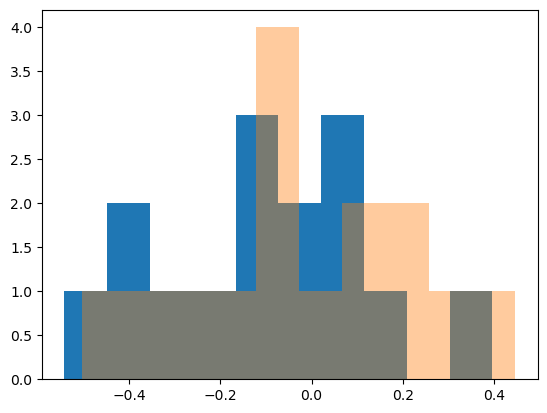

In [66]:
import matplotlib.pyplot as plt 

plt.hist(delta_corr)
plt.hist(delta_raw, alpha=.4)

In [67]:
len(mae_corr_only_corrected_test)

15

In [68]:
# mae improvement

np.mean(mae_corr_only_corrected_test) / np.mean(mae_base_only_corrected_test) - 1

np.float64(-0.03922292351286427)

In [69]:
# rmse improvement

np.mean(rmse_corr_only_corrected_test) / np.mean(rmse_base_only_corrected_test) - 1

np.float64(-0.025201599010988063)

In [70]:
# share of rmse for corr better than for base

a = np.array(rmse_corr_only_corrected_test)
b = np.array(rmse_base_only_corrected_test)

mask = a < b
count = mask.sum()
idxs = np.where(mask)[0]
len(idxs) / len(a)

0.8

In [71]:
# share of bias for corr better than for base

a = np.array(np.abs(bias_corr_only_corrected_test))
b = np.array(np.abs(bias_base_only_corrected_test))

mask = a < b
count = mask.sum()
idxs = np.where(mask)[0]
len(idxs) / len(a)

0.4666666666666667

In [72]:
share_correction

[np.float64(0.5016611295681063),
 np.float64(0.5374149659863946),
 np.float64(0.5226480836236934),
 np.float64(0.5607142857142857),
 np.float64(0.5408163265306123),
 np.float64(0.525096525096525),
 np.float64(0.5408163265306123),
 np.float64(0.521594684385382),
 np.float64(0.23809523809523808),
 np.float64(0.5464285714285714),
 np.float64(0.5873015873015873),
 np.float64(0.6138996138996139),
 np.float64(0.5939849624060151),
 np.float64(0.6177606177606177),
 np.float64(0.5959183673469388)]

In [73]:
np.mean(share_correction)

np.float64(0.5362767523782795)

In [ ]:
import matplotlib.pyplot as plt

name = "xgb"
corr = auto_corr.percentile_correction_[name]
corr_ids = list(corr["id_to_col"].keys())
future_exog_plot = test_i[FUTURE_EXOG_COLS].copy()

# raw predictions WITH the needed percentile columns
raw_preds = auto_corr.models_[name].predict(
    h=h,
    X_df=future_exog_plot,
    level=corr["levels"],  # make sure percentile cols exist
)

# corrected predictions (auto_corr.predict applies correction)
corr_preds = auto_corr.predict(h=h, X_df=future_exog_plot)

for uid in corr_ids[0:50]:
    raw_uid = raw_preds[raw_preds["unique_id"] == uid]
    corr_uid = corr_preds[corr_preds["unique_id"] == uid]
    test_uid = test_i[test_i["unique_id"] == uid]
    # valid_uid = valid[valid["unique_id"] == uid]

    #if raw_uid.empty or corr_uid.empty or valid_uid.empty:
    #    continue

    plt.figure(figsize=(10, 4))
    # plt.plot(valid_uid["ds"], valid_uid["y"], label="Actuals (valid.y)", color="black", alpha=0.8)
    plt.plot(raw_uid["ds"], raw_uid[name], label="Raw forecast", alpha=0.8)
    plt.plot(corr_uid["ds"], corr_uid[name], label="Corrected forecast", alpha=0.8)
    plt.plot(test_uid["ds"], test_uid['y'], label="True", alpha=0.8)
    plt.title(f"Forecasts for {uid} (corrected: {corr['id_to_col'][uid]})")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print((raw_uid[name].sum(),
              corr_uid[name].sum(),
              test_uid['y'].sum()
              ))

In [75]:
forecast_df = pd.concat(forecast_records, ignore_index=True) if forecast_records else pd.DataFrame()
selected_percentiles_df = pd.concat(selected_percentile_records, ignore_index=True) if selected_percentile_records else pd.DataFrame()
fold_metrics_df = pd.concat(fold_metric_records, ignore_index=True) if fold_metric_records else pd.DataFrame()
train_history_df = pd.concat(train_history_records, ignore_index=True) if train_history_records else pd.DataFrame()

if not forecast_df.empty:
    forecast_df = forecast_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)
if not selected_percentiles_df.empty:
    selected_sort_cols = [
        col for col in ['fold', 'sales_group', 'unique_id', 'weekday', 'horizon']
        if col in selected_percentiles_df.columns
    ]
    selected_percentiles_df = selected_percentiles_df.sort_values(selected_sort_cols).reset_index(drop=True)
if not fold_metrics_df.empty:
    fold_metrics_df = fold_metrics_df.sort_values('fold').reset_index(drop=True)
if not train_history_df.empty:
    train_history_df = train_history_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)


## Day-Type Analytics (Weekday vs Weekend)

Evaluate correction quality by day type and weekday, both overall and within each sales segment.

In [76]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

day_eval_df = forecast_df.copy()
day_eval_df['weekday_name'] = day_eval_df['weekday_name'].astype(str)
day_eval_df['is_weekend'] = day_eval_df['weekday'].isin([5, 6])
day_eval_df['day_type'] = np.where(day_eval_df['is_weekend'], 'weekend', 'weekday')
day_eval_df['abs_gap_improvement'] = day_eval_df['raw_abs_error'] - day_eval_df['corr_abs_error']
day_eval_df['bias_reduction'] = np.abs(day_eval_df['raw_error']) - np.abs(day_eval_df['corr_error'])

def _metric_summary(g):
    return pd.Series({
        'n_rows': len(g),
        'raw_rmse': np.sqrt(np.mean(np.square(g['raw_error']))),
        'corrected_rmse': np.sqrt(np.mean(np.square(g['corr_error']))),
        'raw_bias': g['raw_error'].mean(),
        'corrected_bias': g['corr_error'].mean(),
        'rmse_improvement': np.sqrt(np.mean(np.square(g['raw_error']))) - np.sqrt(np.mean(np.square(g['corr_error']))),
        'bias_abs_improvement': np.abs(g['raw_error'].mean()) - np.abs(g['corr_error'].mean()),
        'mean_abs_gap_improvement': g['abs_gap_improvement'].mean(),
        'improved_share': g['improved'].mean(),
        'was_corrected_share': g['was_corrected'].mean(),
    })

overall_daytype_summary = day_eval_df.groupby('day_type', as_index=False).apply(_metric_summary).reset_index(drop=True)
overall_weekday_summary = day_eval_df.groupby('weekday_name', as_index=False).apply(_metric_summary).reset_index(drop=True)
overall_weekday_summary['weekday_name'] = pd.Categorical(overall_weekday_summary['weekday_name'], categories=weekday_order, ordered=True)
overall_weekday_summary = overall_weekday_summary.sort_values('weekday_name').reset_index(drop=True)

segment_daytype_summary = day_eval_df.groupby(['sales_group', 'day_type'], as_index=False).apply(_metric_summary).reset_index(drop=True)
segment_daytype_summary['sales_group'] = pd.Categorical(
    segment_daytype_summary['sales_group'],
    categories=['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct', 'ALL'],
    ordered=True,
)
segment_daytype_summary = segment_daytype_summary.sort_values(['sales_group', 'day_type']).reset_index(drop=True)

display(overall_daytype_summary)
display(overall_weekday_summary)
display(segment_daytype_summary.head(20))

/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_94214/2010749753.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_daytype_summary = day_eval_df.groupby('day_type', as_index=False).apply(_metric_summary).reset_index(drop=True)
/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_94214/2010749753.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_weekday_summary = day_eval_df.grou

,day_type,n_rows,raw_rmse,corrected_rmse,raw_bias,corrected_bias,rmse_improvement,bias_abs_improvement,mean_abs_gap_improvement,improved_share,was_corrected_share
0,weekday,3750.0,9.587110,9.615194,0.215616,0.067637,-0.028084,0.147979,0.050265,0.430667,0.501067
1,weekend,1500.0,16.822986,16.851917,-0.622406,-0.675598,-0.028931,-0.053192,0.047770,0.404000,0.464000


,weekday_name,n_rows,raw_rmse,corrected_rmse,raw_bias,corrected_bias,rmse_improvement,bias_abs_improvement,mean_abs_gap_improvement,improved_share,was_corrected_share
0,Mon,750.0,7.398847,7.402544,0.221694,0.035170,-0.003697,0.186524,0.059067,0.417333,0.489333
1,Tue,750.0,4.880185,4.750252,0.168889,0.140602,0.129933,0.028287,0.062045,0.424000,0.490667
2,Wed,750.0,18.451981,18.545620,-0.238904,-0.414056,-0.093639,-0.175152,0.040679,0.441333,0.528000
3,Thu,750.0,4.391635,4.352156,0.676301,0.439183,0.039478,0.237118,0.066969,0.453333,0.504000
4,Fri,750.0,4.608931,4.692116,0.250102,0.137287,-0.083185,0.112815,0.022563,0.417333,0.493333
5,Sat,750.0,23.276068,23.278274,-1.028833,-1.134969,-0.002205,-0.106137,0.053783,0.405333,0.462667
6,Sun,750.0,4.924466,5.108444,-0.215980,-0.216226,-0.183977,-0.000247,0.041757,0.402667,0.465333


,sales_group,day_type,n_rows,raw_rmse,corrected_rmse,raw_bias,corrected_bias,rmse_improvement,bias_abs_improvement,mean_abs_gap_improvement,improved_share,was_corrected_share
0,G1_lowest,weekday,900.0,0.275455,0.136735,0.237110,0.012834,0.138720,0.224276,0.147747,0.946667,1.000000
1,G1_lowest,weekend,360.0,0.309907,0.152907,0.281078,0.009412,0.157000,0.271667,0.178813,0.933333,1.000000
2,G2_low,weekday,900.0,0.889539,0.884272,0.136459,-0.049549,0.005267,0.086910,0.099171,0.651111,0.732222
3,G2_low,weekend,360.0,1.231164,1.231675,0.124660,-0.088824,-0.000511,0.035837,0.112878,0.627778,0.708333
4,G3_mid,weekday,825.0,1.776275,1.831724,0.108923,-0.001587,-0.055449,0.107335,-0.017803,0.088485,0.156364
5,G3_mid,weekend,330.0,2.169018,2.200689,-0.265954,-0.240539,-0.031671,0.025414,-0.018688,0.042424,0.081818
6,G4_high,weekday,900.0,3.684375,3.711100,0.275599,0.171693,-0.026725,0.103907,-0.015991,0.094444,0.168889
7,G4_high,weekend,360.0,5.070334,5.072381,-1.146292,-0.850546,-0.002047,0.295746,-0.019995,0.083333,0.147222
8,G5_top_5pct,weekday,225.0,38.243197,38.344125,0.597550,0.593198,-0.100927,0.004352,-0.020688,0.084444,0.173333
9,G5_top_5pct,weekend,90.0,67.752124,67.869603,-6.436057,-6.658153,-0.117479,-0.222096,-0.222096,0.000000,0.011111


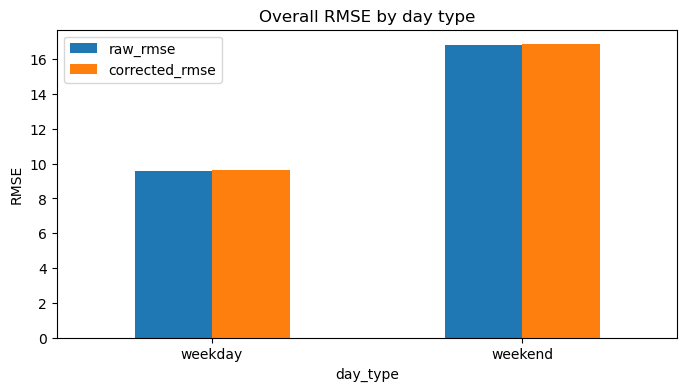

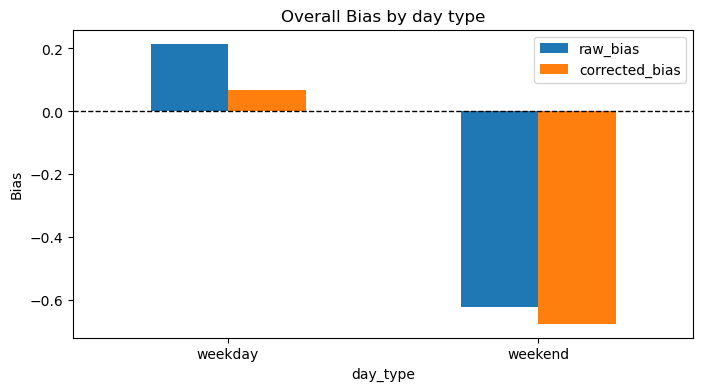

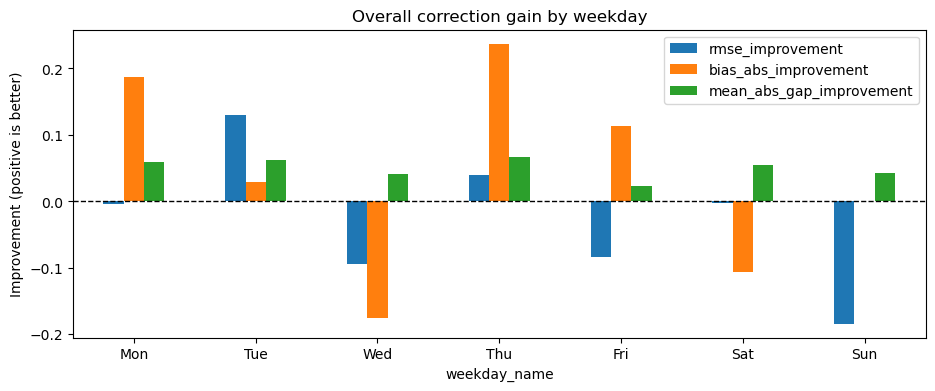

In [77]:
plot_dt = overall_daytype_summary.set_index('day_type')
plot_wd = overall_weekday_summary.set_index('weekday_name')

ax = plot_dt[['raw_rmse', 'corrected_rmse']].plot(kind='bar', figsize=(8, 4))
ax.set_title('Overall RMSE by day type')
ax.set_ylabel('RMSE')
plt.xticks(rotation=0)
plt.show()

ax = plot_dt[['raw_bias', 'corrected_bias']].plot(kind='bar', figsize=(8, 4))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Overall Bias by day type')
ax.set_ylabel('Bias')
plt.xticks(rotation=0)
plt.show()

ax = plot_wd[['rmse_improvement', 'bias_abs_improvement', 'mean_abs_gap_improvement']].plot(kind='bar', figsize=(11, 4))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Overall correction gain by weekday')
ax.set_ylabel('Improvement (positive is better)')
plt.xticks(rotation=0)
plt.show()

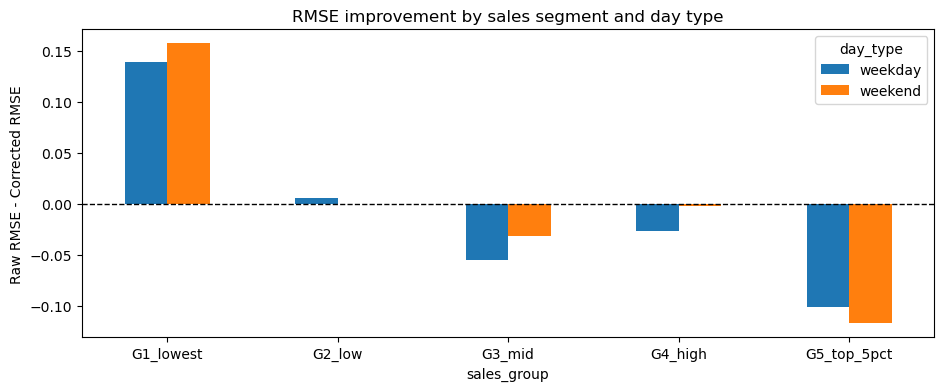

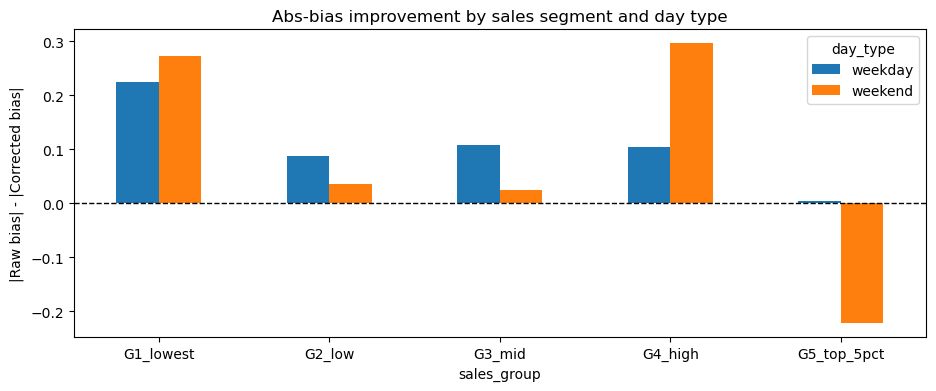

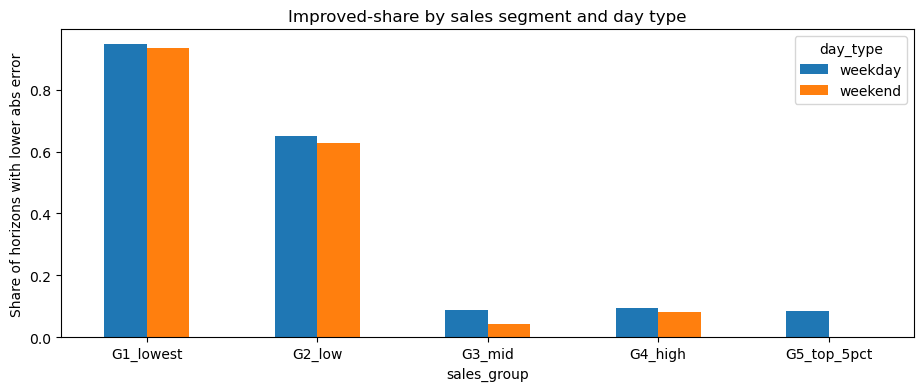

In [78]:
seg_plot = segment_daytype_summary[segment_daytype_summary['sales_group'] != 'ALL'].copy()

seg_rmse = seg_plot.pivot(index='sales_group', columns='day_type', values='rmse_improvement')
ax = seg_rmse.plot(kind='bar', figsize=(11, 4))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('RMSE improvement by sales segment and day type')
ax.set_ylabel('Raw RMSE - Corrected RMSE')
plt.xticks(rotation=0)
plt.show()

seg_bias = seg_plot.pivot(index='sales_group', columns='day_type', values='bias_abs_improvement')
ax = seg_bias.plot(kind='bar', figsize=(11, 4))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Abs-bias improvement by sales segment and day type')
ax.set_ylabel('|Raw bias| - |Corrected bias|')
plt.xticks(rotation=0)
plt.show()

seg_imp = seg_plot.pivot(index='sales_group', columns='day_type', values='improved_share')
ax = seg_imp.plot(kind='bar', figsize=(11, 4))
ax.set_title('Improved-share by sales segment and day type')
ax.set_ylabel('Share of horizons with lower abs error')
plt.xticks(rotation=0)
plt.show()

### Date-Level View

Daily improvement curves across the test windows (overall and by sales segment).

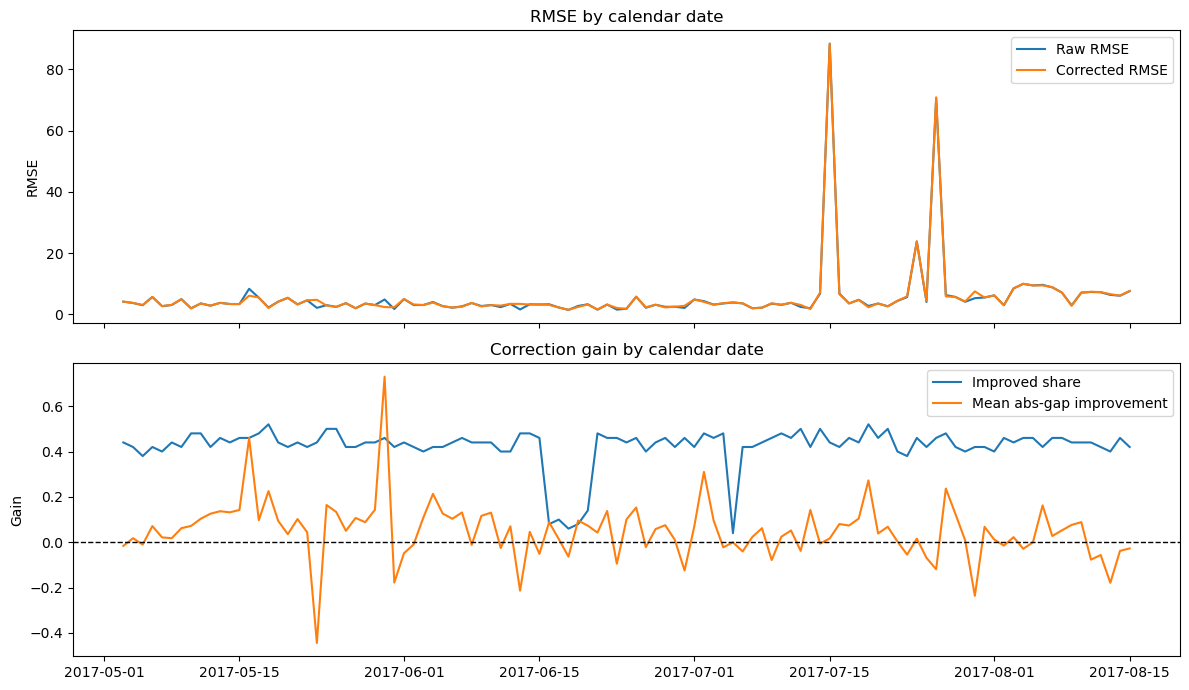

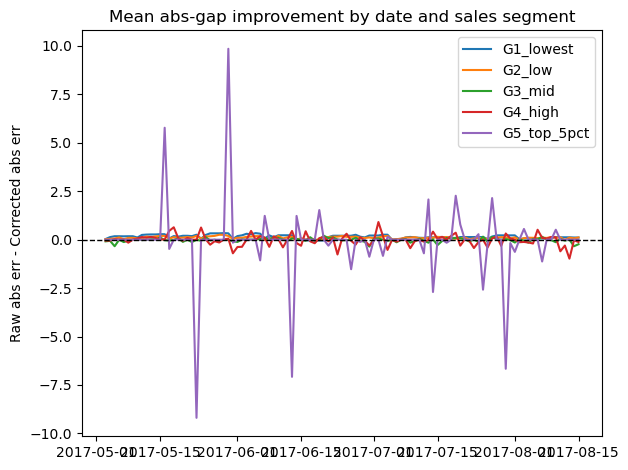

In [79]:
date_summary = day_eval_df.groupby('ds', as_index=False).agg(
    raw_rmse=('raw_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    corrected_rmse=('corr_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    raw_bias=('raw_error', 'mean'),
    corrected_bias=('corr_error', 'mean'),
    improved_share=('improved', 'mean'),
    mean_abs_gap_improvement=('abs_gap_improvement', 'mean'),
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(date_summary['ds'], date_summary['raw_rmse'], label='Raw RMSE')
axes[0].plot(date_summary['ds'], date_summary['corrected_rmse'], label='Corrected RMSE')
axes[0].set_title('RMSE by calendar date')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(date_summary['ds'], date_summary['improved_share'], label='Improved share')
axes[1].plot(date_summary['ds'], date_summary['mean_abs_gap_improvement'], label='Mean abs-gap improvement')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Correction gain by calendar date')
axes[1].set_ylabel('Gain')
axes[1].legend()

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

seg_date_summary = (
    day_eval_df[day_eval_df['sales_group'] != 'ALL']
    .groupby(['ds', 'sales_group'], as_index=False)
    .agg(mean_abs_gap_improvement=('abs_gap_improvement', 'mean'))
)

for grp in ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct']:
    g = seg_date_summary[seg_date_summary['sales_group'] == grp]
    if g.empty:
        continue
    plt.plot(g['ds'], g['mean_abs_gap_improvement'], label=grp)

plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
plt.title('Mean abs-gap improvement by date and sales segment')
plt.ylabel('Raw abs err - Corrected abs err')
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
display(train_history_df.head())
display(forecast_df.head())
display(selected_percentiles_df.head())
display(fold_metrics_df)


,fold,unique_id,ds,y,mean_sales_per_day,sales_group
0,0,1020237__store_36,2017-01-01,0.0,0.0,G1_lowest
1,0,1020237__store_36,2017-01-02,0.0,0.0,G1_lowest
2,0,1020237__store_36,2017-01-03,0.0,0.0,G1_lowest
3,0,1020237__store_36,2017-01-04,0.0,0.0,G1_lowest
4,0,1020237__store_36,2017-01-05,0.0,0.0,G1_lowest


,fold,unique_id,ds,horizon,weekday,weekday_name,y,raw_pred,corr_pred,raw_error,...,corr_abs_error,abs_adjustment,improved,mean_sales_per_day,sales_group,was_corrected,correction_granularity,selected_col,selected_side,selected_percentile
0,0,1020237__store_36,2017-08-09,1,2,Wed,0.0,0.157545,0.083708,0.157545,...,0.083708,0.073838,True,0.0,G1_lowest,True,weekday,xgb-lo-12,lo,12.0
1,0,1020237__store_36,2017-08-10,2,3,Thu,0.0,0.169586,0.033718,0.169586,...,0.033718,0.135868,True,0.0,G1_lowest,True,weekday,xgb-lo-11,lo,11.0
2,0,1020237__store_36,2017-08-11,3,4,Fri,0.0,0.169586,0.046070,0.169586,...,0.046070,0.123517,True,0.0,G1_lowest,True,weekday,xgb-lo-10,lo,10.0
3,0,1020237__store_36,2017-08-12,4,5,Sat,0.0,0.169586,0.046070,0.169586,...,0.046070,0.123517,True,0.0,G1_lowest,True,weekday,xgb-lo-10,lo,10.0
4,0,1020237__store_36,2017-08-13,5,6,Sun,0.0,0.169586,0.046070,0.169586,...,0.046070,0.123517,True,0.0,G1_lowest,True,weekday,xgb-lo-10,lo,10.0


,selected_col,unique_id,weekday,selected_weekday_name,model,selected_side,selected_percentile,correction_granularity,mean_sales_per_day,sales_rank_pct,sales_group,fold
0,xgb-lo-9,1020237__store_36,0,Mon,xgb,lo,9,weekday,0.0,0.02,G1_lowest,0
1,xgb-lo-9,1020237__store_36,1,Tue,xgb,lo,9,weekday,0.0,0.02,G1_lowest,0
2,xgb-lo-12,1020237__store_36,2,Wed,xgb,lo,12,weekday,0.0,0.02,G1_lowest,0
3,xgb-lo-11,1020237__store_36,3,Thu,xgb,lo,11,weekday,0.0,0.02,G1_lowest,0
4,xgb-lo-10,1020237__store_36,4,Fri,xgb,lo,10,weekday,0.0,0.02,G1_lowest,0


,fold,rmse_base,rmse_corr,mse_base,mse_corr,bias_base,bias_corr,n_ids,n_corrected_ids,n_corrected_keys,correction_granularity
0,0,2.550335,2.606805,42.336275,43.126625,0.863521,0.806116,50,43,172,weekday
1,1,2.927584,2.914109,69.416396,69.220146,0.900171,0.752062,50,42,175,weekday
2,2,5.846833,5.870698,736.937964,747.604393,-1.529266,-1.755733,50,41,168,weekday
3,3,3.142900,3.135582,93.973076,94.519622,-0.427524,-0.600143,50,40,175,weekday
4,4,6.692467,6.636010,1136.232492,1136.928558,-1.825829,-1.972981,50,42,176,weekday
5,5,1.890186,1.881532,10.170433,10.290116,0.779681,0.695377,50,37,167,weekday
6,6,2.041226,1.982545,11.396925,11.598273,-0.175870,-0.255394,50,42,177,weekday
7,7,1.744939,1.696608,9.256494,9.607407,-0.028591,-0.128840,50,43,171,weekday
8,8,1.680924,1.644582,8.013162,7.516727,0.362122,0.145693,50,42,177,weekday
9,9,1.804817,1.805731,7.928790,9.435158,-0.042499,-0.125380,50,40,172,weekday


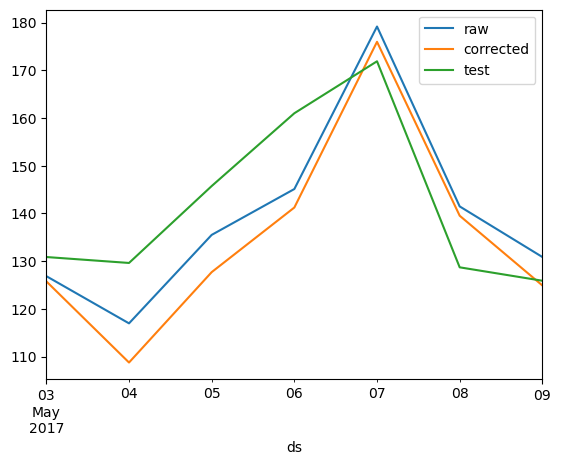

In [81]:
raw_preds.groupby('ds').xgb.sum().plot(label='raw')
corr_preds.groupby('ds').xgb.sum().plot(label='corrected')
test_i.groupby('ds').y.sum().plot(label='test')
plt.legend()
plt.show()

In [82]:
def plot_uid_fold(uid, fold, history_points=None):
    hist = train_history_df[
        (train_history_df['fold'] == fold) &
        (train_history_df['unique_id'] == uid)
    ].copy().sort_values('ds')

    fut = forecast_df[
        (forecast_df['fold'] == fold) &
        (forecast_df['unique_id'] == uid)
    ].copy().sort_values('ds')

    if hist.empty or fut.empty:
        print('No data for this uid/fold')
        return

    if history_points is not None:
        hist = hist.tail(history_points)

    meta = fut[['sales_group', 'mean_sales_per_day', 'was_corrected', 'correction_granularity']].iloc[0]
    choice_df = fut[['weekday_name', 'horizon', 'selected_col']].drop_duplicates()
    choice_df = choice_df[choice_df['selected_col'].notna()]
    if choice_df.empty:
        choice_summary = 'none'
    else:
        choice_summary = ', '.join(
            f"h{row.horizon}:{row.weekday_name}:{row.selected_col}"
            for row in choice_df.itertuples(index=False)
        )

    plt.figure(figsize=(12, 5))
    plt.plot(hist['ds'], hist['y'], label='Train history', color='black', alpha=0.8)
    plt.plot(fut['ds'], fut['raw_pred'], label='Raw forecast', alpha=0.8)
    plt.plot(fut['ds'], fut['corr_pred'], label='Corrected forecast', alpha=0.8)
    plt.plot(fut['ds'], fut['y'], label='True', alpha=0.8)
    plt.title(
        f"fold={fold} | uid={uid} | group={meta['sales_group']} | "
        f"mean_sales={meta['mean_sales_per_day']:.3f} | "
        f"corrected={meta['was_corrected']} | "
        f"granularity={meta['correction_granularity']} | "
        f"choices={choice_summary}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(
        fut[[
            'ds', 'weekday_name', 'horizon', 'y', 'raw_pred', 'corr_pred',
            'raw_error', 'corr_error',
            'raw_abs_error', 'corr_abs_error',
            'abs_adjustment', 'improved',
            'selected_side', 'selected_percentile', 'selected_col'
        ]]
    )


def plot_random_from_each_group(fold=0, n_per_group=2, corrected_only=False, history_points=60, seed=42):
    rng = np.random.default_rng(seed)
    groups = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct']

    base = (
        forecast_df[forecast_df['fold'] == fold][
            ['unique_id', 'sales_group', 'was_corrected', 'mean_sales_per_day']
        ]
        .drop_duplicates()
    )

    for group in groups:
        cand = base[base['sales_group'] == group].copy()
        if corrected_only:
            cand = cand[cand['was_corrected']]

        if cand.empty:
            print(f'{group}: no ids available')
            continue

        sampled = rng.choice(cand['unique_id'].to_numpy(), size=min(n_per_group, len(cand)), replace=False)
        print(f'\n=== {group} ===')
        for uid in sampled:
            plot_uid_fold(uid, fold=fold, history_points=history_points)


In [83]:
group_order = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct', 'ALL']

group_sum_df = pd.concat(group_sum_records, ignore_index=True)
group_correction_df = pd.concat(group_correction_records, ignore_index=True)
forecast_df = pd.concat(forecast_records, ignore_index=True)
selected_percentiles_df = pd.concat(selected_percentile_records, ignore_index=True) if selected_percentile_records else pd.DataFrame()
fold_metrics_df = pd.concat(fold_metric_records, ignore_index=True)
train_history_df = pd.concat(train_history_records, ignore_index=True)

forecast_df = forecast_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)
if not selected_percentiles_df.empty:
    selected_sort_cols = [
        col for col in ['fold', 'sales_group', 'unique_id', 'weekday', 'horizon']
        if col in selected_percentiles_df.columns
    ]
    selected_percentiles_df = selected_percentiles_df.sort_values(selected_sort_cols).reset_index(drop=True)
fold_metrics_df = fold_metrics_df.sort_values('fold').reset_index(drop=True)
train_history_df = train_history_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)

group_sum_summary = group_sum_df.groupby('sales_group', as_index=False).agg(
    true_sum=('true_sum', 'sum'),
    raw_sum=('raw_sum', 'sum'),
    corrected_sum=('corrected_sum', 'sum'),
)
group_sum_summary['raw_to_true_ratio'] = group_sum_summary['raw_sum'] / group_sum_summary['true_sum']
group_sum_summary['corrected_to_true_ratio'] = group_sum_summary['corrected_sum'] / group_sum_summary['true_sum']
group_sum_summary['raw_pct_error'] = group_sum_summary['raw_to_true_ratio'] - 1
group_sum_summary['corrected_pct_error'] = group_sum_summary['corrected_to_true_ratio'] - 1

group_correction_summary = group_correction_df.groupby('sales_group', as_index=False).agg(
    avg_n_ids=('n_ids', 'mean'),
    avg_corrected_ids=('n_corrected_ids', 'mean'),
    avg_corrected_keys=('n_corrected_keys', 'mean'),
    avg_corrected_keys_per_corrected_id=('avg_corrected_keys_per_corrected_id', 'mean'),
    correction_coverage=('correction_coverage', 'mean'),
    adjustment_share=('adjustment_share', 'mean'),
    improved_share=('improved_share', 'mean'),
    mean_sales_min=('mean_sales_min', 'mean'),
    mean_sales_max=('mean_sales_max', 'mean'),
)

group_error_summary = forecast_df.groupby('sales_group', as_index=False).agg(
    raw_rmse=('raw_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    corrected_rmse=('corr_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    raw_bias=('raw_error', 'mean'),
    corrected_bias=('corr_error', 'mean'),
)
group_error_summary = pd.concat([
    group_error_summary,
    pd.DataFrame({
        'sales_group': ['ALL'],
        'raw_rmse': [np.sqrt(np.mean(np.square(forecast_df['raw_error'])))],
        'corrected_rmse': [np.sqrt(np.mean(np.square(forecast_df['corr_error'])))],
        'raw_bias': [forecast_df['raw_error'].mean()],
        'corrected_bias': [forecast_df['corr_error'].mean()],
    })
], ignore_index=True)

group_summary = group_sum_summary.merge(group_correction_summary, on='sales_group', how='left')
group_summary = group_summary.merge(group_error_summary, on='sales_group', how='left')
group_summary['sales_group'] = pd.Categorical(group_summary['sales_group'], categories=group_order, ordered=True)
group_summary = group_summary.sort_values('sales_group').reset_index(drop=True)
group_summary


,sales_group,true_sum,raw_sum,corrected_sum,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,avg_n_ids,avg_corrected_ids,...,avg_corrected_keys_per_corrected_id,correction_coverage,adjustment_share,improved_share,mean_sales_min,mean_sales_max,raw_rmse,corrected_rmse,raw_bias,corrected_bias
0,G1_lowest,0.000,314.586731,14.938666,inf,inf,inf,inf,12.0,12.000000,...,7.000000,1.000000,1.014119,0.942857,0.000000,0.000000,0.285723,0.141545,0.249672,0.011856
1,G2_low,329.628,497.318634,253.057098,1.508727,0.767705,0.508727,-0.232295,12.0,11.666667,...,5.228788,0.972222,0.530003,0.644444,0.000000,0.400011,0.999137,0.995973,0.133088,-0.060771
2,G3_mid,1648.119,1650.215454,1567.431519,1.001272,0.951043,0.001272,-0.048957,11.0,6.933333,...,1.501746,0.630303,0.092044,0.075325,0.515912,1.907854,1.896803,1.944300,0.001815,-0.069859
3,G4_high,5798.007,5633.381348,5646.333984,0.971607,0.973840,-0.028393,-0.026160,12.0,7.466667,...,1.881878,0.622222,0.081757,0.091270,2.280944,8.198114,4.128121,4.145900,-0.130655,-0.120376
4,G5_top_5pct,6188.707,5743.910645,5722.942871,0.928128,0.924740,-0.071872,-0.075260,3.0,1.600000,...,1.564103,0.533333,0.048667,0.060317,12.556868,21.923006,48.540721,48.644373,-1.412052,-1.478617
5,ALL,13964.461,13839.413086,13204.704102,0.991045,0.945594,-0.008955,-0.054406,50.0,39.666667,...,4.343453,0.793333,0.104192,0.423048,0.000000,21.923006,12.104245,12.131623,-0.023819,-0.144716


In [84]:
group_summary[[
    'sales_group', 'true_sum', 'raw_sum', 'corrected_sum',
    'raw_to_true_ratio', 'corrected_to_true_ratio',
    'raw_rmse', 'corrected_rmse', 'raw_bias', 'corrected_bias',
    'correction_coverage', 'avg_corrected_ids', 'avg_corrected_keys',
    'avg_corrected_keys_per_corrected_id',
    'adjustment_share', 'improved_share',
    'mean_sales_min', 'mean_sales_max'
]]


,sales_group,true_sum,raw_sum,corrected_sum,raw_to_true_ratio,corrected_to_true_ratio,raw_rmse,corrected_rmse,raw_bias,corrected_bias,correction_coverage,avg_corrected_ids,avg_corrected_keys,avg_corrected_keys_per_corrected_id,adjustment_share,improved_share,mean_sales_min,mean_sales_max
0,G1_lowest,0.000,314.586731,14.938666,inf,inf,0.285723,0.141545,0.249672,0.011856,1.000000,12.000000,84.000000,7.000000,1.014119,0.942857,0.000000,0.000000
1,G2_low,329.628,497.318634,253.057098,1.508727,0.767705,0.999137,0.995973,0.133088,-0.060771,0.972222,11.666667,60.933333,5.228788,0.530003,0.644444,0.000000,0.400011
2,G3_mid,1648.119,1650.215454,1567.431519,1.001272,0.951043,1.896803,1.944300,0.001815,-0.069859,0.630303,6.933333,10.400000,1.501746,0.092044,0.075325,0.515912,1.907854
3,G4_high,5798.007,5633.381348,5646.333984,0.971607,0.973840,4.128121,4.145900,-0.130655,-0.120376,0.622222,7.466667,13.666667,1.881878,0.081757,0.091270,2.280944,8.198114
4,G5_top_5pct,6188.707,5743.910645,5722.942871,0.928128,0.924740,48.540721,48.644373,-1.412052,-1.478617,0.533333,1.600000,2.666667,1.564103,0.048667,0.060317,12.556868,21.923006
5,ALL,13964.461,13839.413086,13204.704102,0.991045,0.945594,12.104245,12.131623,-0.023819,-0.144716,0.793333,39.666667,171.666667,4.343453,0.104192,0.423048,0.000000,21.923006


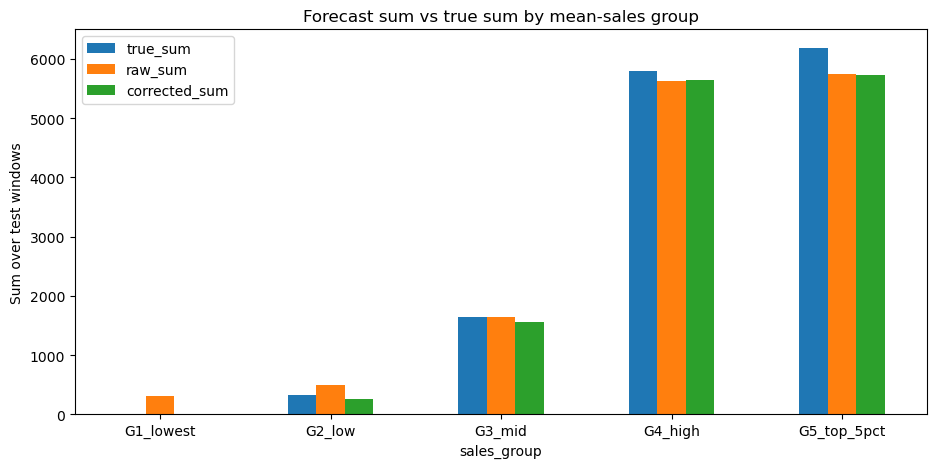

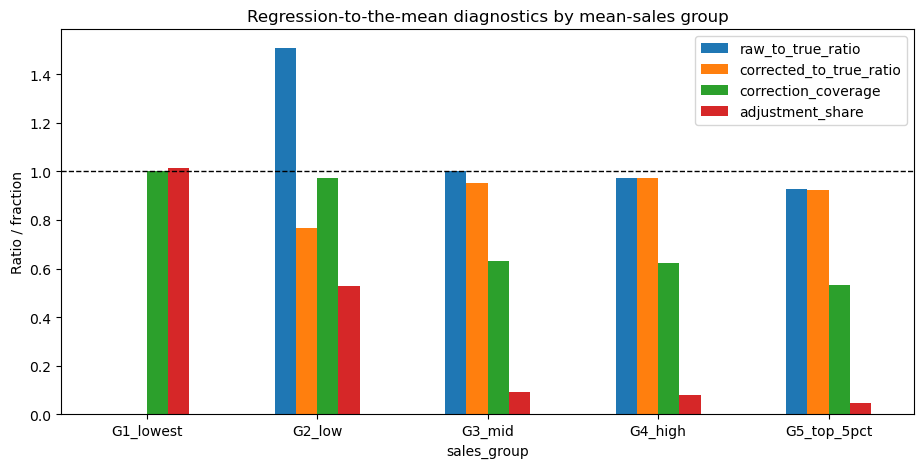

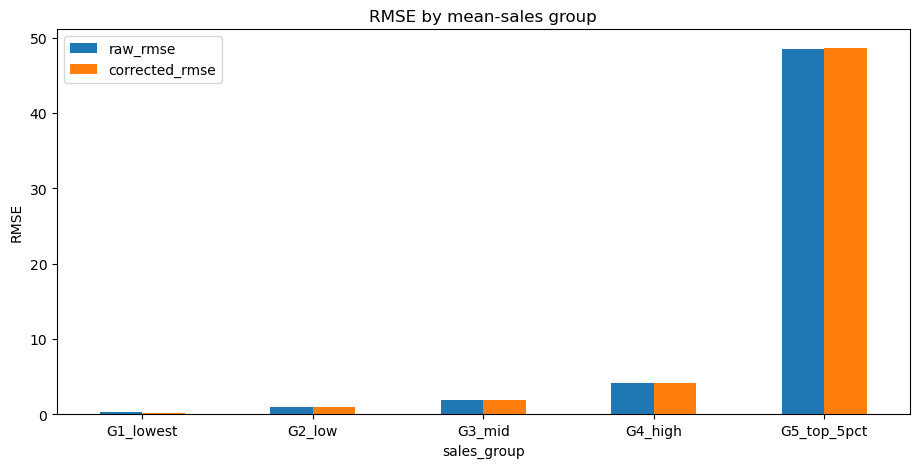

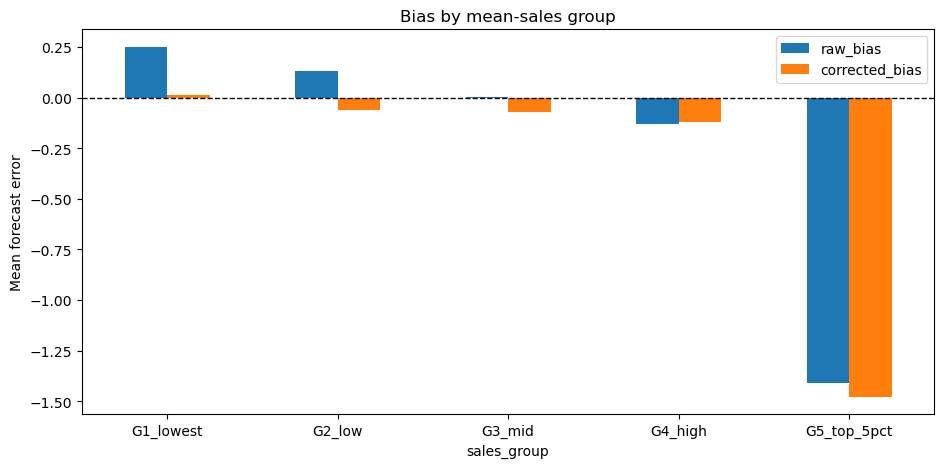

In [85]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')

plot_groups = group_summary[group_summary['sales_group'] != 'ALL'].copy()
bottom_groups = [g for g in group_order[:2] if g in set(plot_groups['sales_group'].astype(str))]
bottom_group_labels = {
    'G1_lowest': 'Lowest',
    'G2_low': 'Low',
    'G0_bottom5': 'Bottom 5%',
    'G1_low_5_to_20': '5-20%',
}

raw_color = '#4C78A8'
corrected_color = '#F58518'
grid_color = '#D9D9D9'


def scientific_barplot(ax, data, title, ylabel, hline=None):
    data.plot(kind='bar', ax=ax, color=[raw_color, corrected_color], width=0.72)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Mean-sales group', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(axis='y', color=grid_color, linewidth=0.8)
    ax.grid(axis='x', visible=False)
    if hline is not None:
        ax.axhline(hline, color='#333333', linestyle='--', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9)


# Keep the broader context plots across all groups.
ax = plot_groups.set_index('sales_group')[['true_sum', 'raw_sum', 'corrected_sum']].plot(kind='bar', figsize=(11, 5))
ax.set_title('Forecast sum vs true sum by mean-sales group')
ax.set_ylabel('Sum over test windows')
plt.xticks(rotation=0)
plt.show()

ax = plot_groups.set_index('sales_group')[['raw_to_true_ratio', 'corrected_to_true_ratio', 'correction_coverage', 'adjustment_share']].plot(kind='bar', figsize=(11, 5))
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Regression-to-the-mean diagnostics by mean-sales group')
ax.set_ylabel('Ratio / fraction')
plt.xticks(rotation=0)
plt.show()

# Focus the error plots on the two lowest mean-sales groups.
if not bottom_groups:
    print('No bottom sales groups found. Run the loop and aggregation cells first.')
else:
    bottom_summary = plot_groups[plot_groups['sales_group'].astype(str).isin(bottom_groups)].copy()
    bottom_summary['sales_group_label'] = bottom_summary['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_summary['sales_group'].astype(str))
    bottom_summary = bottom_summary.set_index('sales_group_label')

    fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
    scientific_barplot(
        ax,
        bottom_summary[['raw_rmse', 'corrected_rmse']].rename(columns={'raw_rmse': 'Raw', 'corrected_rmse': 'Corrected'}),
        'RMSE in the two lowest mean-sales groups (Grocery)',
        'RMSE',
    )
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
    scientific_barplot(
        ax,
        bottom_summary[['raw_bias', 'corrected_bias']].rename(columns={'raw_bias': 'Raw', 'corrected_bias': 'Corrected'}),
        'Bias in the two lowest mean-sales groups (Grocery)',
        'Mean forecast error',
        hline=0.0,
    )
    fig.tight_layout()
    plt.show()

    forecast_for_wrmse = None
    if 'forecast_eval_df' in globals() and forecast_eval_df is not None and not forecast_eval_df.empty:
        forecast_for_wrmse = forecast_eval_df.copy()
    elif 'forecast_df' in globals() and forecast_df is not None and not forecast_df.empty:
        forecast_for_wrmse = forecast_df.copy()

    if forecast_for_wrmse is not None and 'train_history_df' in globals() and not train_history_df.empty:
        corrected_col = 'corrected_pred' if 'corrected_pred' in forecast_for_wrmse.columns else 'corr_pred'
        if {'fold', 'unique_id', 'raw_pred', corrected_col, 'y', 'sales_group'}.issubset(forecast_for_wrmse.columns):
            train_weight_col = 'train_mean_sales' if 'train_mean_sales' in train_history_df.columns else 'mean_sales_per_day'
            weight_df = (
                train_history_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby(['fold', 'unique_id'], as_index=False)
                .agg(train_weight=(train_weight_col, 'mean'))
            )
            wrmse_df = forecast_for_wrmse.assign(unique_id=lambda d: d['unique_id'].astype(str)).merge(
                weight_df, on=['fold', 'unique_id'], how='left'
            )
            wrmse_df = wrmse_df[wrmse_df['sales_group'].astype(str).isin(bottom_groups)].copy()
            wrmse_df['weight'] = wrmse_df['train_weight'].clip(lower=0).fillna(0)
            if wrmse_df['weight'].sum() == 0:
                wrmse_df['weight'] = 1.0
            wrmse_df['raw_sq_err'] = (wrmse_df['raw_pred'] - wrmse_df['y']) ** 2
            wrmse_df['corrected_sq_err'] = (wrmse_df[corrected_col] - wrmse_df['y']) ** 2

            bottom_wrmse = (
                wrmse_df.groupby('sales_group', observed=True)
                .apply(lambda g: pd.Series({
                    'raw_wrmse': np.sqrt(np.average(g['raw_sq_err'], weights=g['weight'])),
                    'corrected_wrmse': np.sqrt(np.average(g['corrected_sq_err'], weights=g['weight'])),
                }))
                .reset_index()
            )
            bottom_wrmse['sales_group_label'] = bottom_wrmse['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_wrmse['sales_group'].astype(str))
            bottom_wrmse = bottom_wrmse.set_index('sales_group_label')
            display(bottom_wrmse)

            fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
            scientific_barplot(
                ax,
                bottom_wrmse[['raw_wrmse', 'corrected_wrmse']].rename(columns={'raw_wrmse': 'Raw', 'corrected_wrmse': 'Corrected'}),
                'Train-sales weighted RMSE in the two lowest groups (Grocery)',
                'WRMSE',
            )
            fig.tight_layout()
            plt.show()
        else:
            print('Forecast diagnostics do not have the required columns for WRMSE.')
    else:
        print('Forecast diagnostics or train_history_df is empty; cannot compute WRMSE.')
